# Feature Selection Pipeline — GA-EN (Amini & Hu, 2020)

This notebook is the **single-source-of-truth** for choosing which predictors feed the production PINN landslide model.

**Pipeline:**
1. Load + preprocess the dataset (mirrors the training notebook so selection sees the same feature distributions the PINN will train on).
2. Run the GA-EN two-layer selection (`select_features`).
3. Generate analytics: per-feature decision table with statistical evidence, GA-frequency plot, Layer-2 coefficient plot, Mutual-Information cross-check.
4. Save the final feature list to a manifest JSON.
5. The training notebook loads that manifest and trains on the selected subset — it does **not** re-run selection.

**Why this is a separate notebook:** selection is a slow, stochastic search (~5 GA repeats × 10 generations × pop 50). You want to run it once per dataset/preprocessing-change, audit the results, then freeze the feature list before doing dozens of PINN training runs.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from py_files.data import preprocessing_v2, log_transform_skewed, clip_outliers
from py_files.helpers import add_soil_texture_index
from py_files.feature_selection_ga_en import (
    select_features,
    feature_selection_report,
    MANDATORY_PHYSICS_COLS_V3,
)

In [2]:
# ---- Paths and configuration ----
FILE_PATH      = "~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_17_training_v3_contri.gpkg"
MANIFEST_PATH  = PROJECT_ROOT / "feature_manifests" / "v1_cotabato.json"
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)

PGA_COL = "PGA2_max"

# Mandatory features — physics layers depend on these by name. Never selected/pruned.
MANDATORY = MANDATORY_PHYSICS_COLS_V3 + [PGA_COL]
print("Mandatory (held out of GA):", MANDATORY)
print("Manifest will be saved to:", MANIFEST_PATH)

Mandatory (held out of GA): ['Slope_mean', 'BUK_mean', 'Prc_mean', 'ContributingFactor_mean', 'SoilThc_mean', 'soil_texture_idx', 'PGA2_max']
Manifest will be saved to: /Users/giogonzales/Documents/ml-prep/mlprep/feature_manifests/v1_cotabato.json


## 1. Load + preprocess (mirror training pipeline)

We must apply the same transforms the PINN will see at training time so feature selection is judged on the same distributions.

In [ ]:
COLUMNS_DROP = [
    'Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds',
    'cohesion', 'internal_friction', 'sus_pinn_landslide',
    'confusion', 'landslide_preds', 'landslide_probability',
    'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC',
    'LITHO_2', 'LITHODESC_2', 'value',
]
PHYSICS_FEATURES = {
    'Slope_mean', 'BUK_mean', 'PGA2_max',
    'Prc_mean', 'ContributingFactor_mean',
    'SoilThc_mean', 'LULC_majority',
}

df = gpd.read_file(FILE_PATH)
print(f"Raw dataset: {len(df)} rows")

df, columns, numeric_cols = preprocessing_v2(df, columns_drop=COLUMNS_DROP)
df, _ = log_transform_skewed(df, numeric_cols, skew_threshold=1.0, exclude=PHYSICS_FEATURES)
df, _ = clip_outliers(
    df, [c for c in numeric_cols if c not in PHYSICS_FEATURES],
    lower_pct=1, upper_pct=99,
)
df = add_soil_texture_index(df[columns].copy())
print(f"Final shape: {df.shape}, landslide rate: {df['landslide'].mean():.3f}")

Raw dataset: 60594 rows
  Preprocessing report:
    Starting rows:        60594  (landslide=6820)
    Dropped (Slope < 10): 0  (landslide=0)
    Columns with nulls (model inputs):   {'type': np.int64(1032)}
    Dropped (NaN in ['landslide', 'type']): 1032
    Final rows:           59562  (landslide=6615)
    log1p(NDVI_mean)  skew was -1.67
    log1p(DistFlt_min)  skew was 1.31
    log1p(Distrv_min)  skew was 1.87
    log1p(distrd_min)  skew was 1.87
    Clipped Clay_mean: [313.0000, 432.9952] (1183 values)
    Clipped Sand_mean: [282.0000, 388.8641] (1185 values)
    Clipped Silt_mean: [229.0000, 358.0000] (1176 values)
    Clipped NDVI_mean: [0.3996, 0.6247] (1192 values)
    Clipped Est_mean: [-0.9935, 0.9872] (1189 values)
    Clipped Nrt_mean: [-0.9926, 0.9918] (1192 values)
    Clipped HorCurv_mean: [-0.0925, 0.0606] (1192 values)
    Clipped VertCurv_mean: [-0.0316, 0.0122] (1190 values)
    Clipped Elev_mean: [74.2448, 1939.0204] (1192 values)
    Clipped DistFlt_min: [2.3979, 

TypeError: tuple indices must be integers or slices, not list

## 2. Run GA-EN feature selection

Layer 1 (GA) searches binary feature-inclusion vectors using a logistic-EN surrogate scored by AUC.
Layer 2 (EN) tunes (α, ρ) on the survivor subset, then drops features whose tuned-EN coefficient shrinks below `coef_eps` under L1.

Mandatory physics features are excluded from the search and concatenated back unconditionally.

In [ ]:
CANDIDATE_NUMERIC = [c for c in numeric_cols if c not in MANDATORY]
CANDIDATE_CATEGORICAL = ["type"]

selection_df = df[
    CANDIDATE_NUMERIC + CANDIDATE_CATEGORICAL + MANDATORY + ["landslide"]
].dropna()
print(f"Selection set: {len(selection_df)} rows after dropping NaNs")
print(f"Candidates: {len(CANDIDATE_NUMERIC)} numeric + {len(CANDIDATE_CATEGORICAL)} categorical")

selection = select_features(
    df=selection_df,
    target="landslide",
    mandatory_cols=MANDATORY,
    candidate_numeric=CANDIDATE_NUMERIC,
    candidate_categorical=CANDIDATE_CATEGORICAL,
    fsp=0.5,
    w_auc=0.8,
    w_size=0.2,
    coef_eps=1e-6,
    random_state=42,
    verbose=True,
)

Selection set: 59562 rows after dropping NaNs
Candidates: 14 numeric + 1 categorical
GA-EN: 15 candidate features (14 numeric + 1 categorical), 7 mandatory features (held out).
--- GA repeat 1/5 ---
  [GA repeat 1] gen 1/10  best fitness=0.2955  selected=6/15
  [GA repeat 1] gen 2/10  best fitness=0.2849  selected=5/15
  [GA repeat 1] gen 3/10  best fitness=0.2740  selected=4/15
  [GA repeat 1] gen 4/10  best fitness=0.2687  selected=4/15
  [GA repeat 1] gen 5/10  best fitness=0.2601  selected=3/15
  [GA repeat 1] gen 6/10  best fitness=0.2584  selected=3/15
  [GA repeat 1] gen 7/10  best fitness=0.2583  selected=3/15
  [GA repeat 1] gen 8/10  best fitness=0.2520  selected=2/15
  [GA repeat 1] gen 9/10  best fitness=0.2520  selected=2/15
  [GA repeat 1] gen 10/10  best fitness=0.2520  selected=2/15
--- GA repeat 2/5 ---
  [GA repeat 2] gen 1/10  best fitness=0.2926  selected=5/15
  [GA repeat 2] gen 2/10  best fitness=0.2870  selected=5/15
  [GA repeat 2] gen 3/10  best fitness=0.2599 

## 3. Per-feature decision report

For every candidate, the table shows:

- **ga_frequency** — fraction of GA repeats it appeared in (Layer-1 voting).
- **passed_fsp** — survived the FSP threshold (≥ 0.5).
- **l2_coef_magnitude** — total |coefficient| from the Layer-2 logistic Elastic Net.
- **passed_l2** — survived L1 shrinkage in Layer 2.
- **decision** — one of `KEPT_MANDATORY` / `KEPT_BY_GA_AND_L2` / `DROPPED_AT_L1` / `DROPPED_AT_L2`.

Plus three independent statistical checks against the `landslide` target so the selection is interpretable:

- **mean_pos / mean_neg / cohens_d** — class-conditional means and standardized effect size.
- **mwu_p** — Mann-Whitney U p-value (does the distribution differ between classes?).
- **mi_score** — Mutual Information (model-free signal estimate).

Strong selected features should have high Cohen's d, low MWU p, and high MI. Dropped features should look noise-like on all three.

In [ ]:
report = feature_selection_report(
    df=selection_df,
    target="landslide",
    result=selection,
    mandatory_cols=MANDATORY,
    candidate_numeric=CANDIDATE_NUMERIC,
    candidate_categorical=CANDIDATE_CATEGORICAL,
)

# Pretty-print with sensible precision
fmt = {
    "ga_frequency": "{:.2f}".format,
    "l2_coef_magnitude": "{:.4f}".format,
    "mean_pos": "{:.4g}".format,
    "mean_neg": "{:.4g}".format,
    "mean_abs_diff": "{:.4g}".format,
    "cohens_d": "{:.3f}".format,
    "mwu_p": "{:.2e}".format,
    "mi_score": "{:.4f}".format,
}
report_display = report.copy()
for col, f in fmt.items():
    report_display[col] = report_display[col].apply(lambda v: f(v) if pd.notna(v) else "")
report_display

,feature,role,ga_frequency,passed_fsp,l2_coef_magnitude,passed_l2,decision,mean_pos,mean_neg,mean_abs_diff,cohens_d,mwu_p,mi_score
0,Slope_mean,mandatory,,None,,None,KEPT_MANDATORY,28.53,22.75,5.778,0.678,0.00e+00,
1,BUK_mean,mandatory,,None,,None,KEPT_MANDATORY,11.45,11.35,0.1035,0.154,7.85e-09,
2,Prc_mean,mandatory,,None,,None,KEPT_MANDATORY,203.1,220.2,17.06,-0.535,6.47e-288,
3,ContributingFactor_mean,mandatory,,None,,None,KEPT_MANDATORY,1.916e+04,2.73e+04,8136,-0.029,0.00e+00,
4,SoilThc_mean,mandatory,,None,,None,KEPT_MANDATORY,13.99,13.53,0.4615,0.077,6.14e-10,
5,soil_texture_idx,mandatory,,None,,None,KEPT_MANDATORY,7.32,7.542,0.2214,-0.179,1.13e-36,
6,PGA2_max,mandatory,,None,,None,KEPT_MANDATORY,0.2755,0.248,0.02744,0.314,6.88e-148,
7,type,candidate_categorical,1.00,True,1.4643,True,KEPT_BY_GA_AND_L2,,,,,,0.0144
8,Elev_mean,candidate_numeric,1.00,True,0.4820,True,KEPT_BY_GA_AND_L2,716.9,710,6.859,0.016,1.93e-05,0.1225
9,Clay_mean,candidate_numeric,0.00,False,,False,DROPPED_AT_L1,368.7,370.5,1.74,-0.073,6.03e-05,0.1077


## 4. Layer-1 GA frequencies — which features the search consistently picks

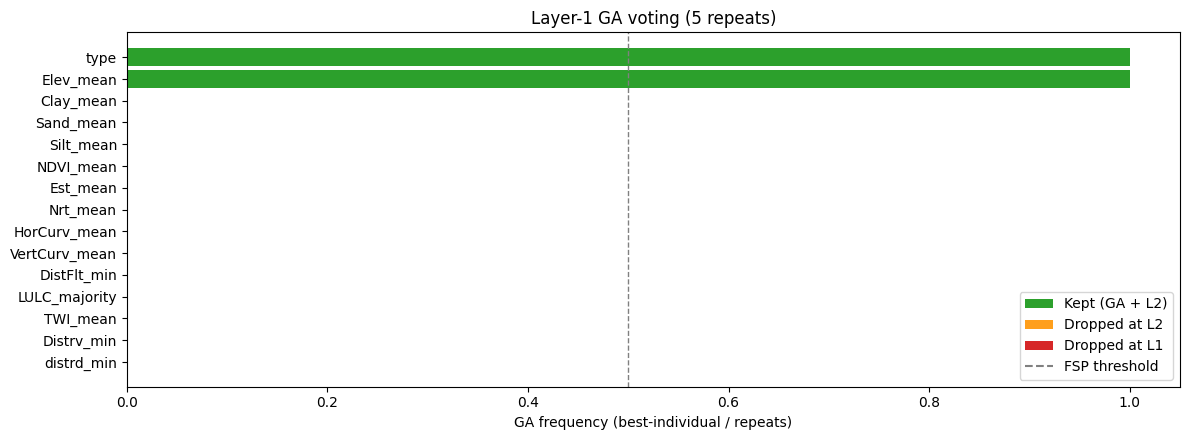

In [ ]:
# Bar chart: GA frequency per candidate. Mandatory features shown for completeness.
freq_df = report[report['role'] != 'mandatory'].copy()
freq_df = freq_df.sort_values('ga_frequency', ascending=False)
colors = freq_df['decision'].map({
    'KEPT_BY_GA_AND_L2': '#2ca02c',
    'DROPPED_AT_L2': '#ff9f1c',
    'DROPPED_AT_L1': '#d62728',
})

fig, ax = plt.subplots(figsize=(12, max(4, 0.3 * len(freq_df))))
ax.barh(freq_df['feature'], freq_df['ga_frequency'], color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='FSP threshold')
ax.set_xlabel('GA frequency (best-individual / repeats)')
ax.set_title('Layer-1 GA voting (5 repeats)')
ax.invert_yaxis()
ax.legend(loc='lower right')

# Inline legend for color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='Kept (GA + L2)'),
    Patch(facecolor='#ff9f1c', label='Dropped at L2'),
    Patch(facecolor='#d62728', label='Dropped at L1'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='gray', linestyle='--', label='FSP threshold')
], loc='lower right')
fig.tight_layout()
plt.show()

## 5. Layer-2 coefficient magnitudes — only Layer-1 survivors are visible to Layer 2

Bar height = total |coef| from the tuned logistic Elastic Net (α, ρ). Features the L1 penalty sent to zero appear missing or near-zero — those are the L2-pruned features.

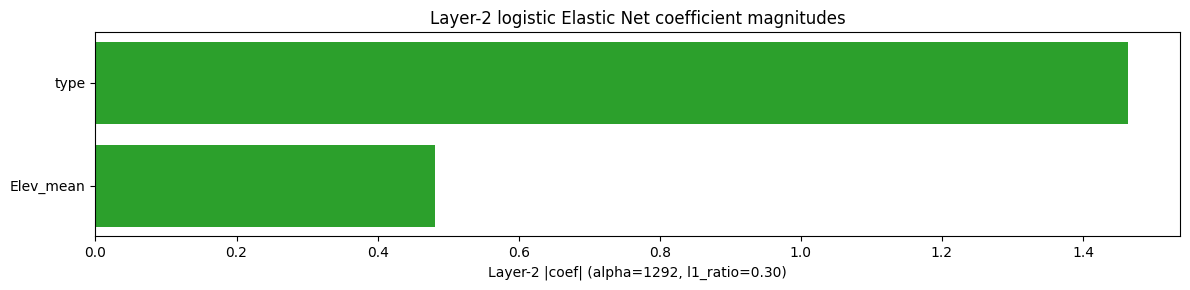

In [ ]:
coef_df = report[report['role'] != 'mandatory'].copy()
coef_df = coef_df[coef_df['l2_coef_magnitude'].notna()]
coef_df = coef_df.sort_values('l2_coef_magnitude', ascending=False)

if len(coef_df) == 0:
    print("No Layer-1 survivors — nothing to plot for Layer 2.")
else:
    fig, ax = plt.subplots(figsize=(12, max(3, 0.35 * len(coef_df))))
    bar_colors = coef_df['decision'].map({
        'KEPT_BY_GA_AND_L2': '#2ca02c',
        'DROPPED_AT_L2': '#ff9f1c',
    })
    ax.barh(coef_df['feature'], coef_df['l2_coef_magnitude'], color=bar_colors)
    ax.set_xlabel(f"Layer-2 |coef| (alpha={selection['en_alpha']:.4g}, l1_ratio={selection['en_l1_ratio']:.2f})")
    ax.set_title('Layer-2 logistic Elastic Net coefficient magnitudes')
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## 6. Independent cross-check — Mutual Information vs GA-EN ranking

If the GA-EN selection is sound, the features it kept should also rank high on a model-free Mutual Information score. Strong agreement = the selection isn't an artefact of the surrogate model.

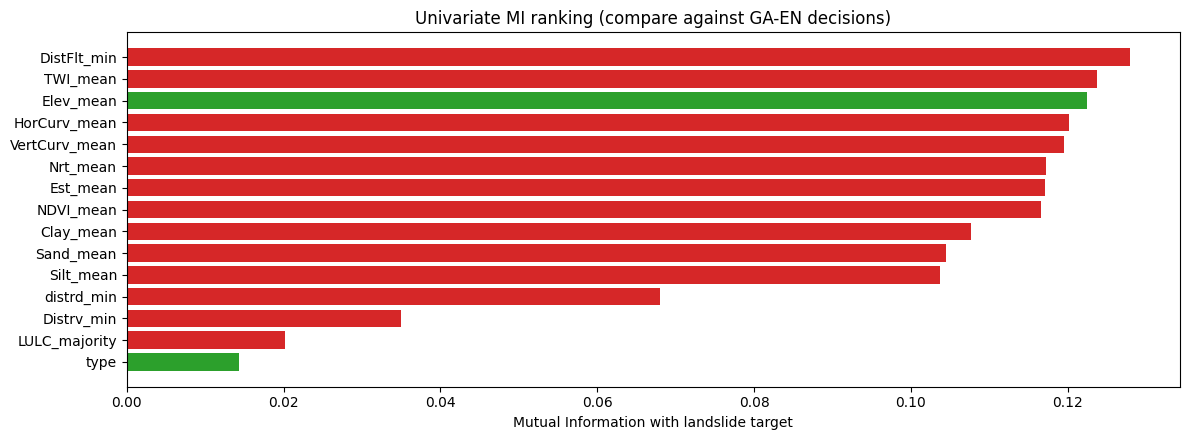

Spearman correlation (ga_frequency, mi_score): rho=-0.091, p=7.476e-01


In [ ]:
mi_df = report[report['role'] != 'mandatory'].copy()
mi_df = mi_df.sort_values('mi_score', ascending=False)
colors = mi_df['decision'].map({
    'KEPT_BY_GA_AND_L2': '#2ca02c',
    'DROPPED_AT_L2': '#ff9f1c',
    'DROPPED_AT_L1': '#d62728',
})

fig, ax = plt.subplots(figsize=(12, max(4, 0.3 * len(mi_df))))
ax.barh(mi_df['feature'], mi_df['mi_score'], color=colors)
ax.set_xlabel('Mutual Information with landslide target')
ax.set_title('Univariate MI ranking (compare against GA-EN decisions)')
ax.invert_yaxis()
fig.tight_layout()
plt.show()

# Quantitative agreement: Spearman rank correlation between GA-frequency and MI
from scipy.stats import spearmanr
rho, p = spearmanr(mi_df['ga_frequency'], mi_df['mi_score'])
print(f"Spearman correlation (ga_frequency, mi_score): rho={rho:.3f}, p={p:.3e}")

## 7. Compression summary

In [ ]:
n_initial = len(CANDIDATE_NUMERIC) + len(CANDIDATE_CATEGORICAL)
n_l1 = len(selection['ga_survivors'])
n_l2 = n_l1 - len(selection['pruned_by_layer2'])
n_mandatory = len(MANDATORY)

print(f"Layer 0 — Initial candidates:      {n_initial:3d}")
print(f"Layer 1 — GA + FSP survivors:      {n_l1:3d}  (-{n_initial - n_l1} dropped)")
print(f"Layer 2 — EN L1 survivors:         {n_l2:3d}  (-{n_l1 - n_l2} dropped)")
print(f"Mandatory (always included):       {n_mandatory:3d}")
print(f"Final feature count for PINN:      {n_l2 + n_mandatory:3d}  ({n_initial + n_mandatory} -> {n_l2 + n_mandatory})")
reduction_pct = 100 * (1 - (n_l2 + n_mandatory) / (n_initial + n_mandatory))
print(f"Reduction:                          {reduction_pct:.1f}%")

Layer 0 — Initial candidates:       15
Layer 1 — GA + FSP survivors:        2  (-13 dropped)
Layer 2 — EN L1 survivors:           2  (-0 dropped)
Mandatory (always included):         7
Final feature count for PINN:        9  (22 -> 9)
Reduction:                          59.1%


## 8. Save manifest — the production training notebook reads this

The manifest captures everything the training pipeline needs to reproduce the feature subset, plus enough metadata to audit how it was chosen.

In [ ]:
manifest = {
    "version": "v1",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "dataset_path": str(FILE_PATH),
    "target": "landslide",
    "pga_col": PGA_COL,
    "mandatory_cols": list(MANDATORY),
    "candidate_numeric": list(CANDIDATE_NUMERIC),
    "candidate_categorical": list(CANDIDATE_CATEGORICAL),
    "selection_params": {
        "fsp": 0.5,
        "w_auc": 0.8,
        "w_size": 0.2,
        "coef_eps": 1e-6,
        "n_ga_repeats": 5,
        "pop_size": 50,
        "n_generations": 10,
        "random_state": 42,
    },
    "results": {
        "ga_frequencies": selection["frequencies"],
        "ga_survivors": selection["ga_survivors"],
        "pruned_by_layer2": selection["pruned_by_layer2"],
        "l2_coefficients": selection["l2_coefficients"],
        "en_alpha": selection["en_alpha"],
        "en_l1_ratio": selection["en_l1_ratio"],
    },
    "final_features": {
        "numerical": selection["numerical"],
        "categorical": selection["categorical"],
    },
}

with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"Manifest saved: {MANIFEST_PATH}")
print(f"\nFinal numerical ({len(selection['numerical'])}):  {selection['numerical']}")
print(f"Final categorical ({len(selection['categorical'])}): {selection['categorical']}")

Manifest saved: /Users/giogonzales/Documents/ml-prep/mlprep/feature_manifests/v1_cotabato.json

Final numerical (8):  ['Slope_mean', 'BUK_mean', 'Prc_mean', 'ContributingFactor_mean', 'SoilThc_mean', 'soil_texture_idx', 'PGA2_max', 'Elev_mean']
Final categorical (1): ['type']


## 9. Hand-off

The production training notebook (`cotabato_new_slope_unit_v2-8.ipynb`) loads this manifest and trains on `final_features`. To re-run selection (e.g. after changing preprocessing, swapping datasets, or tuning `fsp` / `w_auc`):

1. Edit the relevant cell above.
2. Re-run this notebook.
3. The manifest file is overwritten in place — the training notebook picks up the new list automatically next time it runs.